In [1]:
# ============================================
# 1. IMPORT LIBRARY
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Library berhasil di-import.")

Library berhasil di-import.


In [3]:
# ============================================
# 2. UPLOAD DATASET
# ============================================

uploaded = files.upload()

Saving data.csv to data.csv


In [4]:
import os

print(os.listdir())

['.config', 'data.csv', 'sample_data']


In [5]:
# ============================================
# 3. MEMBACA DATASET
# ============================================

df = pd.read_csv(
    "data.csv",
    encoding="latin1"
)

print("Dataset berhasil dibaca.")
print("Jumlah baris dan kolom:", df.shape)

display(df.head())

Dataset berhasil dibaca.
Jumlah baris dan kolom: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
# ============================================
# 4. DATA UNDERSTANDING
# ============================================

print("Informasi Dataset:")
print()

df.info()

Informasi Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
print("Nama kolom:")
print(df.columns.tolist())

Nama kolom:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [8]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# ============================================
# 5. MISSING VALUE
# ============================================

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Kolom": missing.index,
    "Jumlah Missing": missing.values,
    "Persentase (%)": (missing.values / len(df) * 100).round(2)
})

display(missing_df)

,Kolom,Jumlah Missing,Persentase (%)
0,InvoiceNo,0,0.00
1,StockCode,0,0.00
2,Description,1454,0.27
3,Quantity,0,0.00
4,InvoiceDate,0,0.00
5,UnitPrice,0,0.00
6,CustomerID,135080,24.93
7,Country,0,0.00


In [10]:
# ============================================
# 6. DATA DUPLIKAT
# ============================================

print(
    "Jumlah data duplikat:",
    df.duplicated().sum()
)

Jumlah data duplikat: 5268


In [11]:
# ============================================
# 7. DATA CLEANING
# ============================================

# Copy dataset
df_clean = df.copy()

# Menghapus data duplikat
df_clean = df_clean.drop_duplicates()

# Mengubah InvoiceDate menjadi datetime
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"]
)

# Mengubah InvoiceNo menjadi string
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)

# Menghapus transaksi pembatalan
df_clean = df_clean[
    ~df_clean["InvoiceNo"].str.startswith("C")
]

# Menghapus Quantity <= 0
df_clean = df_clean[
    df_clean["Quantity"] > 0
]

# Menghapus UnitPrice <= 0
df_clean = df_clean[
    df_clean["UnitPrice"] > 0
]

# Menghapus CustomerID yang kosong
df_clean = df_clean.dropna(
    subset=["CustomerID"]
)

print("Ukuran data setelah cleaning:")
print(df_clean.shape)

Ukuran data setelah cleaning:
(392692, 8)


In [12]:
# ============================================
# 8. MEMBUAT REVENUE
# ============================================

df_clean["Revenue"] = (
    df_clean["Quantity"] *
    df_clean["UnitPrice"]
)

display(
    df_clean[
        [
            "InvoiceNo",
            "Description",
            "Quantity",
            "UnitPrice",
            "Revenue"
        ]
    ].head()
)

,InvoiceNo,Description,Quantity,UnitPrice,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34


In [13]:
# ============================================
# 9. RINGKASAN DATA
# ============================================

print("Jumlah transaksi:", len(df_clean))
print(
    "Jumlah pelanggan unik:",
    df_clean["CustomerID"].nunique()
)
print(
    "Jumlah produk unik:",
    df_clean["StockCode"].nunique()
)
print(
    "Jumlah negara:",
    df_clean["Country"].nunique()
)

print(
    "Total Revenue:",
    round(df_clean["Revenue"].sum(), 2)
)

Jumlah transaksi: 392692
Jumlah pelanggan unik: 4338
Jumlah produk unik: 3665
Jumlah negara: 37
Total Revenue: 8887208.89


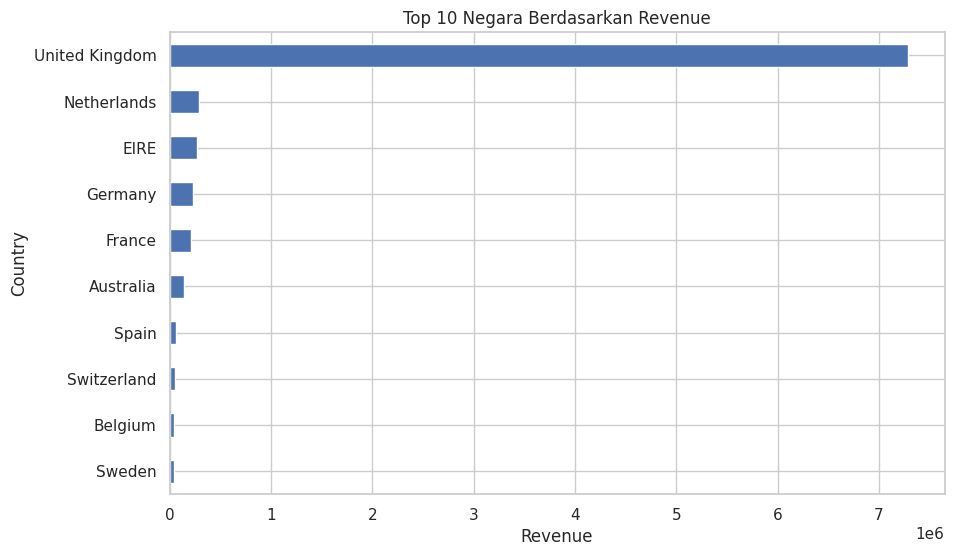

In [14]:
# ============================================
# 10.1 TOP 10 NEGARA
# ============================================

country_revenue = (
    df_clean
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Negara Berdasarkan Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

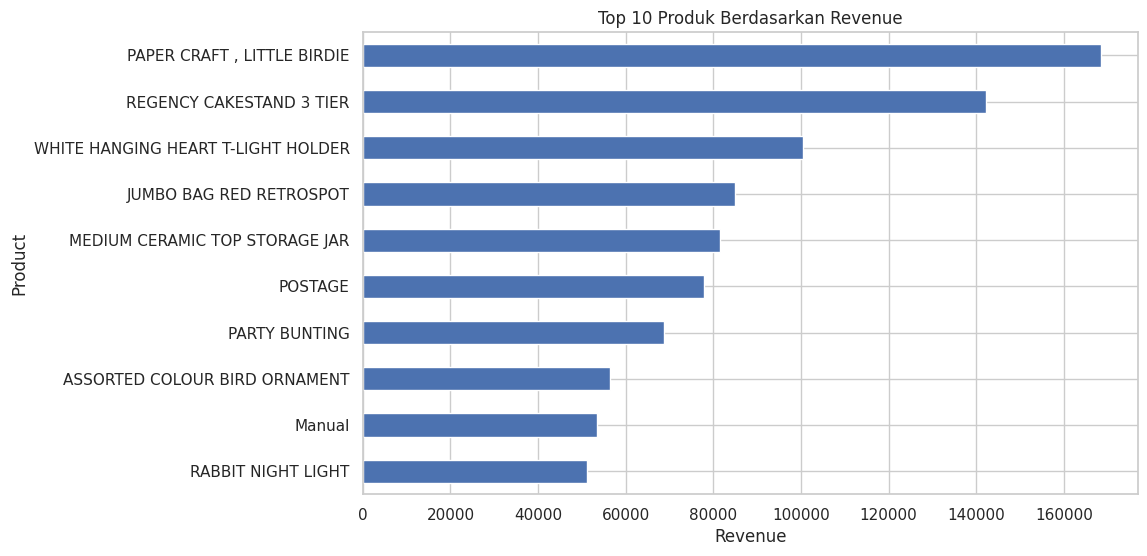

In [15]:
# ============================================
# 11. TOP 10 PRODUK
# ============================================

product_revenue = (
    df_clean
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

product_revenue.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Produk Berdasarkan Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

In [16]:
# ============================================
# 12. TOP 10 CUSTOMER
# ============================================

customer_revenue = (
    df_clean
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(
    customer_revenue.reset_index(
        name="Revenue"
    )
)

,CustomerID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


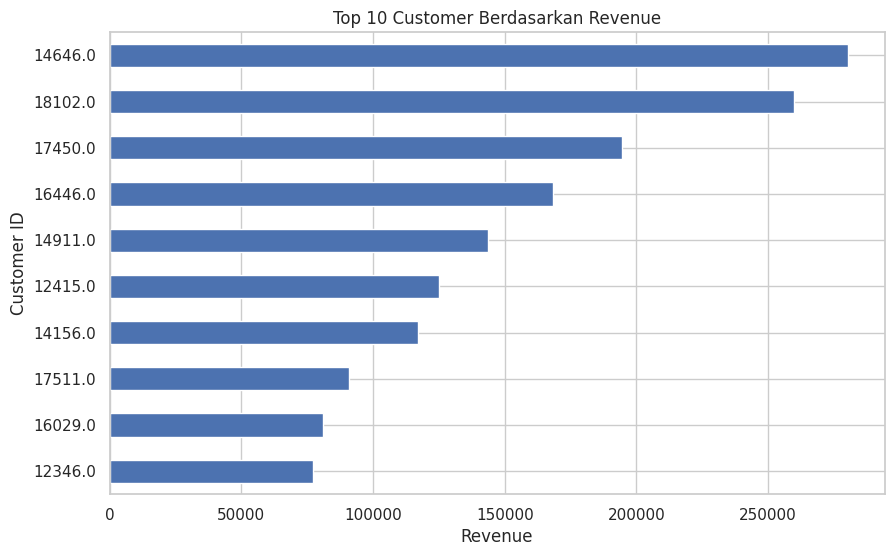

In [17]:
plt.figure(figsize=(10, 6))

customer_revenue.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Customer Berdasarkan Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.show()

In [18]:
# ============================================
# 13. RFM ANALYSIS
# ============================================

reference_date = (
    df_clean["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm = (
    df_clean
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (
                reference_date - x.max()
            ).days
        ),

        Frequency=(
            "InvoiceNo",
            "nunique"
        ),

        Monetary=(
            "Revenue",
            "sum"
        )
    )
    .reset_index()
)

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [19]:
# ============================================
# 14. STATISTIK RFM
# ============================================

display(
    rfm[
        [
            "Recency",
            "Frequency",
            "Monetary"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


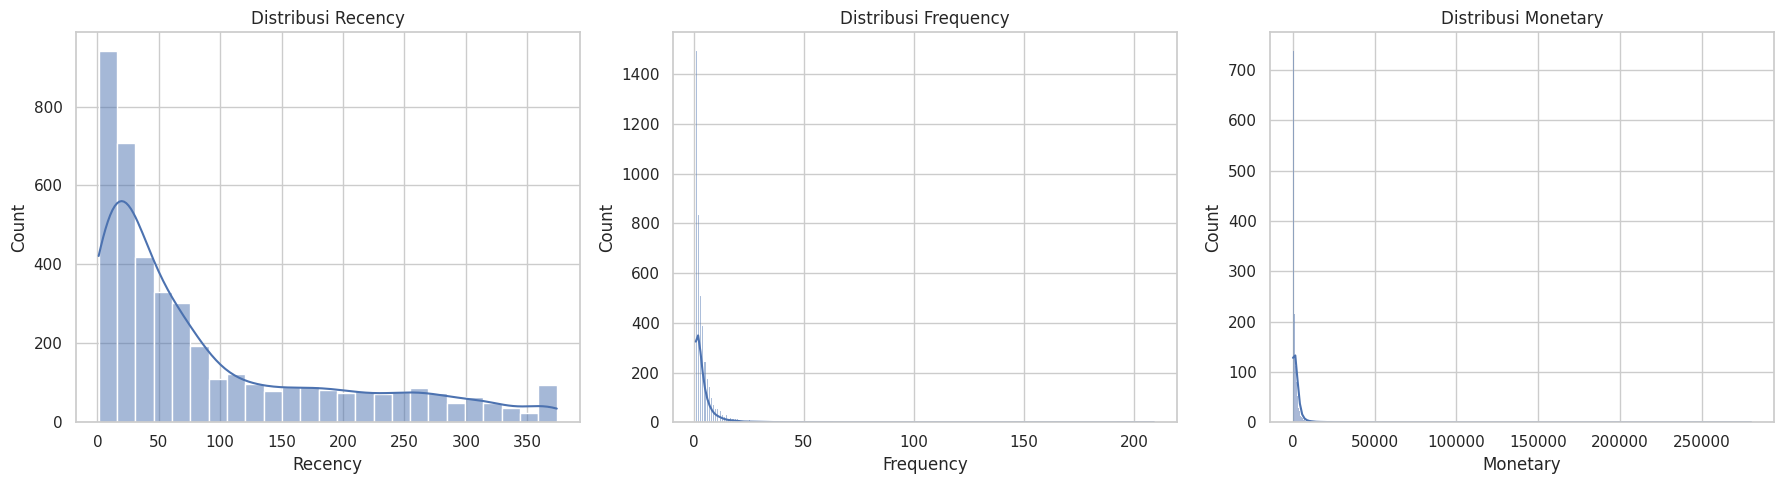

In [20]:
# ============================================
# 15. DISTRIBUSI RFM
# ============================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

sns.histplot(
    rfm["Recency"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title(
    "Distribusi Recency"
)

sns.histplot(
    rfm["Frequency"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title(
    "Distribusi Frequency"
)

sns.histplot(
    rfm["Monetary"],
    kde=True,
    ax=axes[2]
)

axes[2].set_title(
    "Distribusi Monetary"
)

plt.tight_layout()
plt.show()

In [21]:
# ============================================
# 16. LOG TRANSFORMATION
# ============================================

rfm_log = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].copy()

rfm_log = np.log1p(rfm_log)

display(rfm_log.head())

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [22]:
# ============================================
# 17. STANDARDISASI
# ============================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log
)

print(
    "Shape data setelah standardisasi:",
    rfm_scaled.shape
)

Shape data setelah standardisasi: (4338, 3)


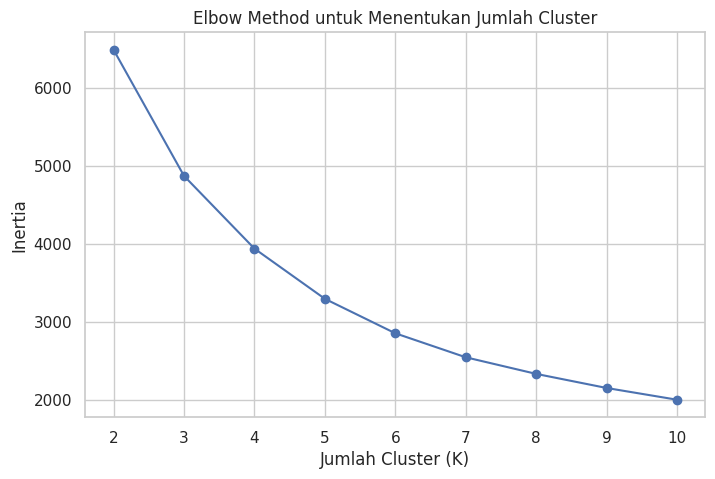

In [23]:
# ============================================
# 18. ELBOW METHOD
# ============================================

inertia = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method untuk Menentukan Jumlah Cluster"
)

plt.xlabel(
    "Jumlah Cluster (K)"
)

plt.ylabel(
    "Inertia"
)

plt.xticks(K)

plt.show()

In [24]:
# ============================================
# 19. SILHOUETTE SCORE
# ============================================

silhouette_scores = {}

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        rfm_scaled
    )

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores[k] = score

silhouette_df = pd.DataFrame(
    list(silhouette_scores.items()),
    columns=[
        "K",
        "Silhouette Score"
    ]
)

display(silhouette_df)

,K,Silhouette Score
0,2,0.432827
1,3,0.336517
2,4,0.337517
3,5,0.316200
4,6,0.312409
5,7,0.309186
6,8,0.303275
7,9,0.281085
8,10,0.276659


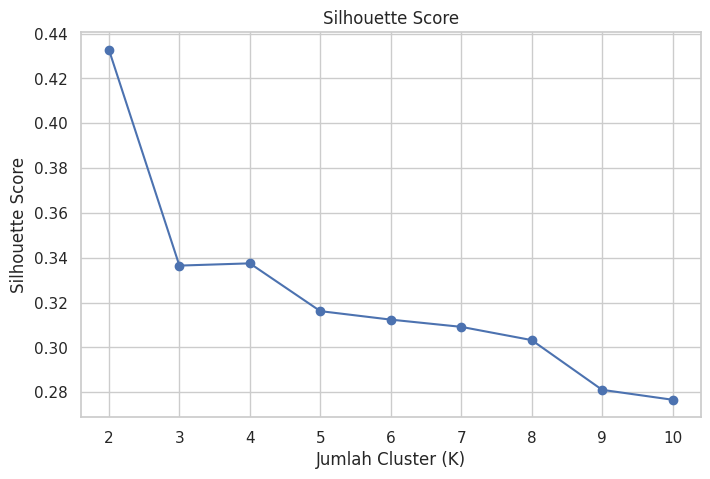

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["K"],
    silhouette_df["Silhouette Score"],
    marker="o"
)

plt.title(
    "Silhouette Score"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")

plt.show()

In [26]:
# ============================================
# 20. K-MEANS CLUSTERING
# ============================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,3
3,12349.0,19,1,1757.55,2
4,12350.0,310,1,334.40,1


In [27]:
# ============================================
# 21. JUMLAH CUSTOMER PER CLUSTER
# ============================================

cluster_count = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

display(
    cluster_count.reset_index(
        name="Jumlah Customer"
    )
)

,Cluster,Jumlah Customer
0,0,713
1,1,1622
2,2,837
3,3,1166


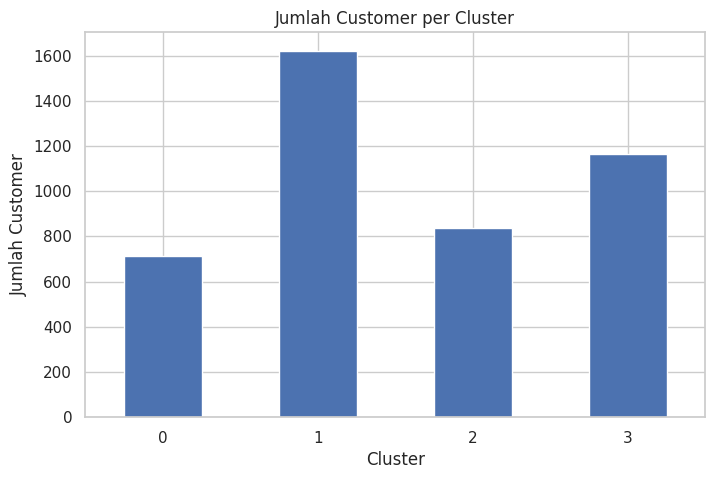

In [28]:
plt.figure(figsize=(8, 5))

cluster_count.plot(
    kind="bar"
)

plt.title(
    "Jumlah Customer per Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Jumlah Customer")

plt.xticks(rotation=0)

plt.show()

In [29]:
# ============================================
# 22. CLUSTER PROFILING
# ============================================

cluster_summary = (
    rfm
    .groupby("Cluster")
    .agg(
        Customer_Count=(
            "CustomerID",
            "count"
        ),

        Avg_Recency=(
            "Recency",
            "mean"
        ),

        Avg_Frequency=(
            "Frequency",
            "mean"
        ),

        Avg_Monetary=(
            "Monetary",
            "mean"
        )
    )
    .round(2)
)

display(cluster_summary)

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,713,12.17,13.75,8088.02
1,1622,181.51,1.32,341.00
2,837,17.70,2.19,557.32
3,1166,71.64,4.08,1801.78


In [30]:
# ============================================
# 23. RANKING CLUSTER
# ============================================

cluster_profile = cluster_summary.copy()

# Recency lebih kecil lebih baik
cluster_profile["Recency_Rank"] = (
    cluster_profile["Avg_Recency"]
    .rank(ascending=True)
)

# Frequency lebih besar lebih baik
cluster_profile["Frequency_Rank"] = (
    cluster_profile["Avg_Frequency"]
    .rank(ascending=False)
)

# Monetary lebih besar lebih baik
cluster_profile["Monetary_Rank"] = (
    cluster_profile["Avg_Monetary"]
    .rank(ascending=False)
)

display(cluster_profile)

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Recency_Rank,Frequency_Rank,Monetary_Rank
Cluster,,,,,,,
0,713,12.17,13.75,8088.02,1.0,1.0,1.0
1,1622,181.51,1.32,341.00,4.0,4.0,4.0
2,837,17.70,2.19,557.32,2.0,3.0,3.0
3,1166,71.64,4.08,1801.78,3.0,2.0,2.0


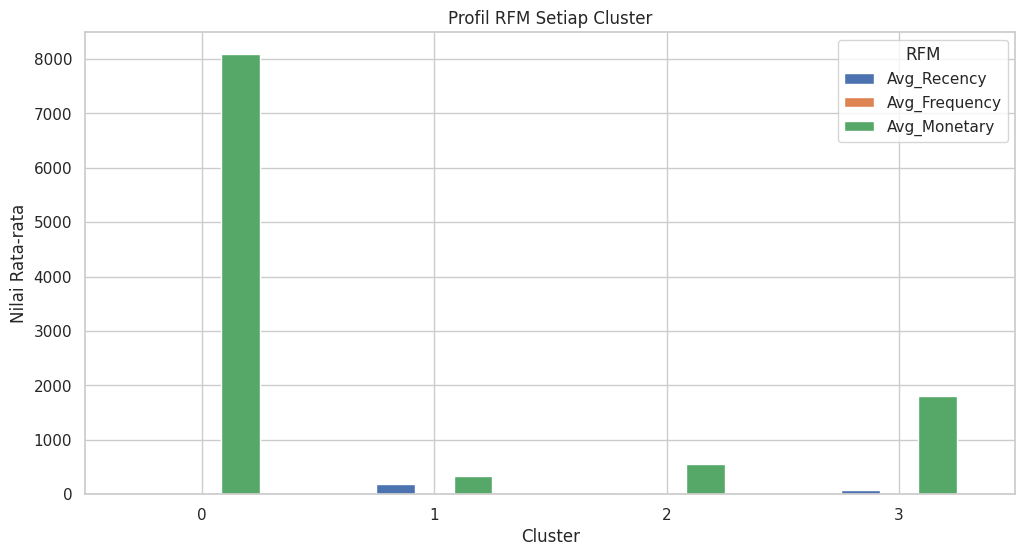

In [31]:
# ============================================
# 24. CLUSTER PROFILE VISUALIZATION
# ============================================

cluster_summary[
    [
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_Monetary"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Profil RFM Setiap Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Nilai Rata-rata")

plt.xticks(rotation=0)

plt.legend(
    title="RFM"
)

plt.show()

In [32]:
# ============================================
# 25. MEMBERIKAN NAMA SEGMENT
# ============================================

# Ranking gabungan
cluster_profile["Overall_Score"] = (
    cluster_profile["Recency_Rank"] +
    cluster_profile["Frequency_Rank"] +
    cluster_profile["Monetary_Rank"]
)

cluster_profile

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Recency_Rank,Frequency_Rank,Monetary_Rank,Overall_Score
Cluster,,,,,,,,
0,713,12.17,13.75,8088.02,1.0,1.0,1.0,3.0
1,1622,181.51,1.32,341.00,4.0,4.0,4.0,12.0
2,837,17.70,2.19,557.32,2.0,3.0,3.0,8.0
3,1166,71.64,4.08,1801.78,3.0,2.0,2.0,7.0


In [33]:
display(
    cluster_profile[
        [
            "Avg_Recency",
            "Avg_Frequency",
            "Avg_Monetary",
            "Overall_Score"
        ]
    ].sort_values(
        "Overall_Score"
    )
)

,Avg_Recency,Avg_Frequency,Avg_Monetary,Overall_Score
Cluster,,,,
0,12.17,13.75,8088.02,3.0
3,71.64,4.08,1801.78,7.0
2,17.70,2.19,557.32,8.0
1,181.51,1.32,341.00,12.0


In [34]:
# ============================================
# 26. SEGMENT CUSTOMER
# ============================================

# CONTOH:
# Ganti mapping ini sesuai hasil cluster_summary kamu.

segment_mapping = {
    0: "Segment 0",
    1: "Segment 1",
    2: "Segment 2",
    3: "Segment 3"
}

rfm["Segment"] = rfm["Cluster"].map(
    segment_mapping
)

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Segment 3
1,12347.0,2,7,4310.00,0,Segment 0
2,12348.0,75,4,1797.24,3,Segment 3
3,12349.0,19,1,1757.55,2,Segment 2
4,12350.0,310,1,334.40,1,Segment 1


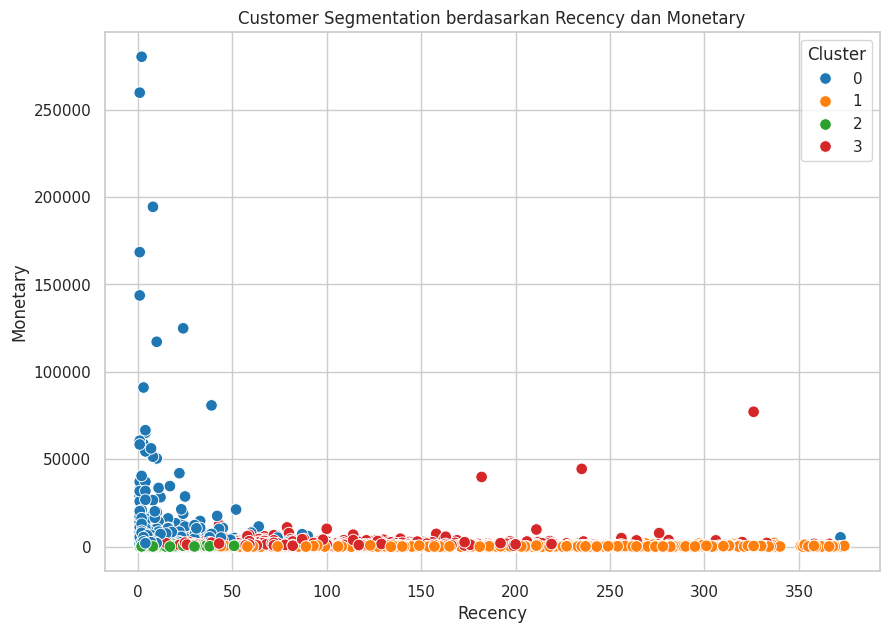

In [35]:
# ============================================
# 27. VISUALISASI CUSTOMER SEGMENT
# ============================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    s=70
)

plt.title(
    "Customer Segmentation berdasarkan Recency dan Monetary"
)

plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()

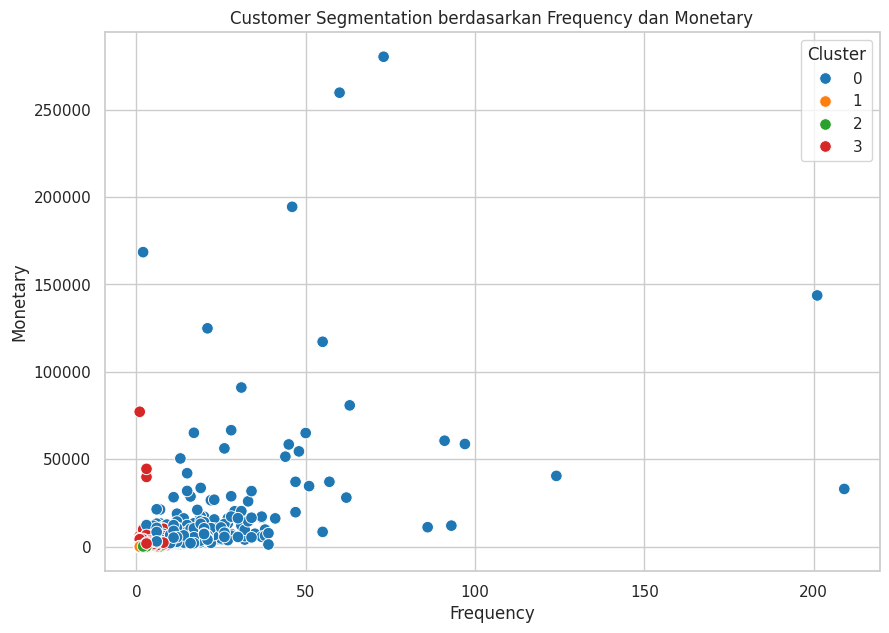

In [36]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    s=70
)

plt.title(
    "Customer Segmentation berdasarkan Frequency dan Monetary"
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

In [37]:
# ============================================
# 29. TOP CUSTOMER
# ============================================

top_customers = (
    rfm
    .sort_values(
        "Monetary",
        ascending=False
    )
    .head(20)
)

display(top_customers)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
1689,14646.0,2,73,280206.02,0,Segment 0
4201,18102.0,1,60,259657.30,0,Segment 0
3728,17450.0,8,46,194390.79,0,Segment 0
3008,16446.0,1,2,168472.50,0,Segment 0
1879,14911.0,1,201,143711.17,0,Segment 0
55,12415.0,24,21,124914.53,0,Segment 0
1333,14156.0,10,55,117210.08,0,Segment 0
3771,17511.0,3,31,91062.38,0,Segment 0
2702,16029.0,39,63,80850.84,0,Segment 0
0,12346.0,326,1,77183.60,3,Segment 3


In [38]:
# ============================================
# 30. EXPORT RFM
# ============================================

rfm.to_csv(
    "rfm_customer_data.csv",
    index=False
)

cluster_summary.to_csv(
    "cluster_summary.csv"
)

print(
    "File hasil berhasil disimpan."
)

File hasil berhasil disimpan.


In [39]:
from google.colab import files

files.download(
    "rfm_customer_data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
files.download(
    "cluster_summary.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>